# 9 · `quiver`

`Map.quiver` renders a vector field from two rasters `(u, v)` as **arrows**, coloured by magnitude (cleopatra `VectorGlyph`). Here `(u, v)` is the DEM's downhill gradient.

**Setup** — inline plots and the path to the bundled Lisbon DEM.

In [1]:
%matplotlib inline
from pathlib import Path

# Locate the bundled Lisbon DEM from the repo root (works from docs/ or the repo root).
ROOT = Path.cwd()
while not (ROOT / "examples" / "data" / "LisbonElevation.tif").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DEM = str(ROOT / "examples" / "data" / "LisbonElevation.tif")
from pyramids.dataset import Dataset
from digitalearth.scene import Map
ds = Dataset.read_file(DEM)
coarse = ds.resample(ds.cell_size * 10)   # downsample for legible markers/cells
import numpy as np
z = np.nan_to_num(coarse.read_array(band=0).astype('float32'))
dy, dx = np.gradient(z)
u = Dataset.create_from_array(arr=(-dx).astype('float32'), geo=coarse.geotransform, epsg=coarse.epsg)
v = Dataset.create_from_array(arr=(dy).astype('float32'), geo=coarse.geotransform, epsg=coarse.epsg)

2026-05-28 20:30:02 | INFO | pyramids.base.config | Logging is configured.


Render the gradient field with `Map.quiver`.

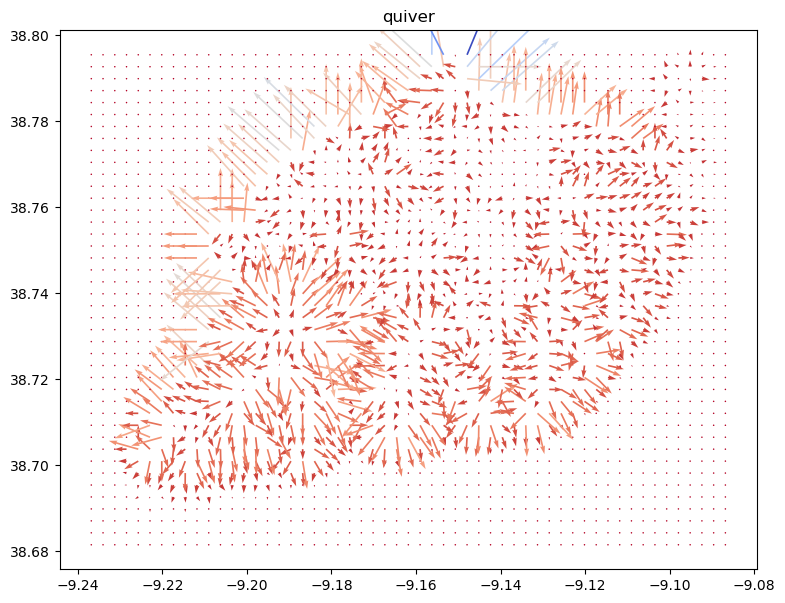

In [2]:
m = Map(crs=coarse.epsg, figsize=(9, 7))
m.quiver(u, v)
m.set_title('quiver')
m.fig;